# Competence models: two models, two inference engines, one API

**Reference.** *Practice Makes Perfect: Planning to Learn Skill Parameter Policies* (Kumar, Silver, et al., 2024), Appendix B.

## The problem

A robot is deployed with a library of parameterized skills (pick, place, sweep, ...) and a planner that chains them. Each skill has a *competence*: the probability that it succeeds when executed. Competences are not fixed. During free time the robot can *practice* a skill, collect a success/failure outcome, and re-train that skill's parameter policy on the accumulated data, so competence tends to rise with practice and then plateau, at a level and a rate that differ from skill to skill. Some skills never improve because they are impossible in the current environment.

The paper's method, EES, decides which skill to practice by asking, for each skill, two questions:

1. **Estimate.** How competent is this skill *right now*, given the outcomes we have seen?
2. **Extrapolate.** How competent *would it be* if we practiced it once more and re-trained?

(A third step, *situate*, feeds those two numbers to the planner to see which improvement helps the task distribution most. It is not part of this notebook.)

A **competence model** is the object that answers those two questions from a stream of success/failure outcomes. The paper fit one by expectation-maximization and found it unstable; here we instead do full Bayesian inference, so that the answers are distributions rather than point estimates and "can this skill still improve?" gets a calibrated probability rather than a guess.

The purpose of this notebook is to make you comfortable with two independent design decisions that any competence model involves, and to see that they really are independent:

- **The model**: what latent quantities we assume exist, and how they evolve as practice data accumulates.
- **The inference algorithm**: how we turn observed outcomes into beliefs about those latent quantities.

## Background: the ideas this notebook uses

A short review, in the notation used below. Skip it if these are familiar.

**Joint distributions and graphical models.** A probabilistic model is a joint distribution over all the quantities involved, observed and unobserved. A directed graphical model (PGM) is a picture of how that joint factorizes: each node is a random variable, each node's distribution is conditioned only on its parents, and the joint is the product of those conditionals. Shaded nodes are observed; unshaded nodes are latent (hidden). A rectangle ("plate") with a label like $k \leq n_j$ means "repeat what is inside $n_j$ times, conditionally independently." Small squares denote known constants (here, data counts). The graph is a statement of conditional-independence assumptions, and those assumptions are what make inference tractable.

**Bayes' rule and inference.** Inference means computing the conditional distribution of the latent variables given the observed ones: the *posterior*. For a latent $z$ and observations $S$,

$$P(z \mid S) = \frac{P(S \mid z)\,P(z)}{P(S)}, \qquad P(S) = \sum_z P(S \mid z)\,P(z).$$

The pieces are the *prior* $P(z)$ (what we believe before seeing data), the *likelihood* $P(S \mid z)$ (how probable the data are under each hypothesis), and the *evidence* $P(S)$, which is just the normalizer. Almost every difficulty in Bayesian inference is the sum (or integral) in $P(S)$: over a continuous or high-dimensional $z$ it has no closed form.

**Marginalization.** Any latent variable we do not care about is summed out. If the model has $(\phi, C_0, \dots, C_J)$ and we want $P(C_J \mid S)$, we sum the posterior over $\phi$ and the other $C_j$. A "nuisance" variable is not a problem for a Bayesian; it is one more sum.

**Bernoulli and Beta.** A skill attempt is a Bernoulli trial with success probability $c$. Given $n$ attempts with $s$ successes, the likelihood is $c^s (1-c)^{n-s}$. The Beta distribution is the standard prior on a probability; it is *conjugate* to the Bernoulli, meaning $\mathrm{Beta}(\alpha,\beta)$ prior plus $(s, n-s)$ observations gives a $\mathrm{Beta}(\alpha+s, \beta+n-s)$ posterior in closed form. We parameterize Betas by their mode $\mu$ and a concentration $\kappa$ ($\alpha = \mu(\kappa-2)+1$, $\beta = (1-\mu)(\kappa-2)+1$) because "most likely competence" and "how sure" are the natural knobs.

**State-space models and filtering.** When the latent state evolves over time, $z_0 \to z_1 \to \dots$, with each $z_j$ depending only on $z_{j-1}$ (the Markov property) and each observation depending only on its own $z_j$, the model is a hidden Markov / state-space model. Inference then splits into named tasks:

- *Filtering:* $P(z_j \mid S_{0:j})$, the belief about the current state given data so far. Computed online by alternating a **predict** step, which pushes the belief through the transition $P(z_j \mid z_{j-1})$, and an **update** step, which multiplies by the likelihood of the new observation and renormalizes.
- *Prediction:* $P(z_{j+h} \mid S_{0:j})$, the predict step applied $h$ times with no update. This is what "extrapolation" is in this notebook.
- *Smoothing:* $P(z_j \mid S_{0:J})$ for $j < J$, the hindsight belief about a past state using all data. Computed by a backward pass on top of the filtered beliefs.

A model in which nothing moves (a static parameter $\phi$) is a degenerate state-space model whose transition is the identity; the same filter handles it.

**Exact inference by discretization.** If every latent variable takes finitely many values, every sum in Bayes' rule is a finite sum and can be computed exactly, with vectors for beliefs and matrices (or structured operators) for transitions. The cost is the size of the state space: a grid of $K$ values per dimension over $d$ dimensions has $K^d$ states, so this is only viable for a few dimensions. The payoff is that there is nothing to tune and nothing to converge.

**Monte Carlo and particle filtering.** The alternative is to represent a belief by samples. A *particle filter* keeps $N$ samples ("particles") of the state: the predict step moves each particle by sampling the transition, the update step weights each particle by its likelihood, and *resampling* then draws a new population in proportion to those weights so that unlikely particles die and likely ones multiply. The result approximates the filtered posterior with error shrinking like $1/\sqrt{N}$, in any number of dimensions. Its characteristic failure is *degeneracy*: if the state contains a component that never changes (like a static $\phi$), resampling only ever deletes values and never creates new ones, so after a few cycles few distinct values survive. MCMC is the other sample-based family: instead of moving particles forward in time, it wanders through the posterior of the full latent vector with a Markov chain whose stationary distribution is the posterior. It is not used here, but a "rejuvenation" step that fixes particle degeneracy is one MCMC move per particle.

**What this buys us.** Two different competence *models* (different latent states and transitions) and two different inference *algorithms* (grid and particles) can be combined freely, because both models are state-space models with a Bernoulli observation and both algorithms are filters that only need a prior, a transition, and a likelihood. The rest of the notebook builds exactly that.

## What we will build

We will write two competence models and two inference algorithms against a shared interface, and then run every combination.

The two **models** differ in what they assume about how competence changes with data:

- **Model A, "global curve."** Competence follows a fixed parametric curve in the amount of training data $m$: it starts at some level, rises exponentially, and saturates at a plateau. The curve's parameters are unknown, so they are latent variables to be inferred. This is the competence model from the paper. It is confident about the future once the curve is pinned down, and it can express "this skill will never improve" directly (a flat curve).
- **Model B, "local trend."** Competence is a quantity that drifts from cycle to cycle, carrying a learning rate that itself decays. Nothing global is assumed about the shape; the model just tracks where competence is and which way it is heading. This is a standard state-space (Kalman-filter-like) formulation.

The two **inference algorithms** differ in how they represent a belief:

- **Grid engine.** Put every latent variable on a finite grid and do the sums in Bayes' rule exactly. No approximation beyond the grid, nothing to tune.
- **Particle engine.** Represent the belief by a cloud of samples that are moved, weighted, and resampled as outcomes arrive (a bootstrap particle filter). Approximate, but indifferent to dimensionality.

|  | Grid engine | Particle engine |
|---|---|---|
| Model A: global curve | exact | approximate |
| Model B: local trend | exact | approximate |

Every cell of the table is produced by the same two engine classes and the same two model classes; nothing is written four times. That is the point.

## Notation shared by both models

A skill's free time is a sequence of *learning cycles* $j = 0, 1, \dots$. Entering cycle $j$ the parameter policy has been trained on $m_j$ data points; during cycle $j$ the skill is attempted $n_j$ times with outcomes $S_{j,k} \sim \mathrm{Bernoulli}(C_j)$, and $m_{j+1} = m_j + n_j$. A cycle is summarized by $(m_j, n_j, s_j)$ with $s_j$ the number of successes. The latent competence $C_j$ is a deterministic function of a per-cycle latent state $z_j$; the two models differ only in what $z_j$ is and how it moves.

In [1]:
from abc import ABC, abstractmethod

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta as beta_dist
from scipy.stats import norm

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110

### Warm-up: Bayes' rule on a grid vs. in closed form

One Bernoulli skill, one cycle, no dynamics. The closed-form Beta posterior and the grid posterior agree; this is the entire mechanism the grid engine repeats cycle after cycle.

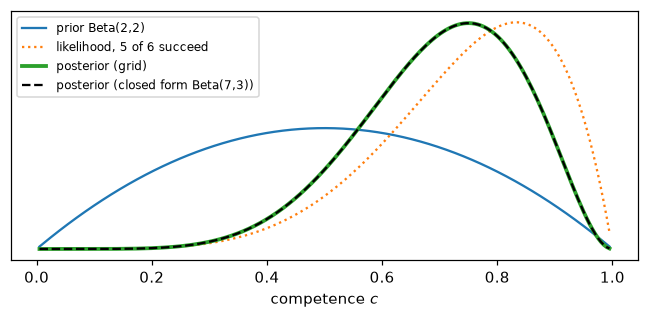

In [2]:
c_grid = np.linspace(0.005, 0.995, 200)
alpha0, beta0, n, s = 2.0, 2.0, 6, 5  # prior Beta(2,2); 5 successes in 6 attempts

prior = beta_dist.pdf(c_grid, alpha0, beta0)
lik = c_grid**s * (1 - c_grid) ** (n - s)
post_grid = prior * lik
post_grid /= post_grid.sum()  # Bayes' rule on the grid
post_closed = beta_dist.pdf(c_grid, alpha0 + s, beta0 + n - s)
post_closed /= post_closed.sum()

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(c_grid, prior / prior.sum(), label="prior Beta(2,2)")
ax.plot(c_grid, lik / lik.sum(), ls=":", label="likelihood, 5 of 6 succeed")
ax.plot(c_grid, post_grid, lw=2.5, label="posterior (grid)")
ax.plot(c_grid, post_closed, ls="--", color="k", label="posterior (closed form Beta(7,3))")
ax.set_xlabel("competence $c$")
ax.set_yticks([])
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## The API

A `CompetenceModel` exposes the generative story twice: once as *samplers* (initial state, transition, competence read-out) for Monte Carlo engines, and once as *discrete operators* (state grid, initial belief, predict operator) for grid engines. Both views describe the same continuous model; the grid view is that model's discretization.

An `InferenceEngine` is a Bayesian filter over cycles. It has exactly three methods that EES uses: `update` (ingest one cycle), `estimate` (belief over current competence), and `extrapolate` (belief over competence after re-learning with $m_{\text{next}}$ data). Both return a weighted sample $\{(c_i, w_i)\}$, which is the common currency between a grid (values = grid points, weights = masses) and a particle set (values = particle competences, weights = uniform after resampling).

Note that `extrapolate` is nothing but the filter's *predict* step applied to a hypothetical future data count. The "estimate / extrapolate" split from the paper is therefore just "filtered belief / one-step prediction" of an ordinary Bayesian filter.

In [3]:
class CompetenceModel(ABC):
    """Generative model of one skill's competence across learning cycles.

    Latent per-cycle state z_j (an array row); competence C_j = competence(z_j).
    Transitions are indexed by data counts: z_{j+1} ~ p(z' | z_j, m_from, m_to),
    where m_from, m_to are the data counts entering cycles j and j+1.
    """

    name = "abstract"

    # ---- sampling view (particle engines, prior visualization) ----
    @abstractmethod
    def sample_initial(self, *, size, rng): ...  # -> z [size, d]
    @abstractmethod
    def sample_transition(self, *, z, m_from, m_to, rng): ...  # -> z' [size, d]
    @abstractmethod
    def competence(self, *, z): ...  # -> c [size] in [0,1]

    # ---- discrete view (grid engines) ----
    @abstractmethod
    def grid_states(self): ...  # -> Z [S, d]
    @abstractmethod
    def grid_initial(self): ...  # -> p [S], sums to 1
    @abstractmethod
    def grid_predict(
        self, *, belief, m_from, m_to
    ): ...  # -> p' [S] = belief pushed through the transition
    @abstractmethod
    def grid_predict_T(
        self, *, v, m_from, m_to
    ): ...  # -> [S]: transpose of grid_predict, v[z] -> sum_z' T(z->z') v[z'] (smoothing only)


class InferenceEngine(ABC):
    """Bayesian filter over learning cycles. This is the interface EES consumes."""

    def __init__(self, *, model: CompetenceModel):
        self.model = model
        self.m_last = None

    @abstractmethod
    def update(self, *, m, n, s): ...  # ingest cycle (m data entering, n attempts, s successes)
    @abstractmethod
    def estimate(self): ...  # -> (values, weights): belief over current competence
    @abstractmethod
    def extrapolate(
        self, *, m_next
    ): ...  # -> (values, weights): belief over competence with m_next data

    # Not used by EES; only for plots and diagnostics.
    @abstractmethod
    def history(
        self,
    ): ...  # -> list over past cycles of (values, weights): SMOOTHED beliefs P(C_j | all data)


def summarize(*, values, weights, q=(0.05, 0.95)):
    """mean and quantiles of a weighted sample"""
    order = np.argsort(values)
    v, w = values[order], weights[order] / weights.sum()
    cdf = np.cumsum(w)
    lo, hi = v[np.searchsorted(cdf, q[0])], v[min(np.searchsorted(cdf, q[1]), len(v) - 1)]
    return float(v @ w), float(lo), float(hi)


def bernoulli_lik(*, c, n, s):
    return c**s * (1.0 - c) ** (n - s)

## Two inference engines

Both engines are written once, against the ABCs, and never mention a specific model.

In [4]:
class GridEngine(InferenceEngine):
    """Exact filtering on the discretized state space, with optional backward smoothing."""

    def __init__(self, *, model):
        super().__init__(model=model)
        self.Z = model.grid_states()
        self.c = model.competence(z=self.Z)
        self.belief = None
        self.filtered, self.liks, self.ms = [], [], []  # forward quantities kept for smoothing

    def _predicted(self, *, m_to):
        if self.belief is None:
            return self.model.grid_initial()
        return self.model.grid_predict(belief=self.belief, m_from=self.m_last, m_to=m_to)

    def update(self, *, m, n, s):
        lik = bernoulli_lik(c=self.c, n=n, s=s)
        b = self._predicted(m_to=m) * lik
        self.belief, self.m_last = b / b.sum(), m
        self.filtered.append(self.belief)
        self.liks.append(lik)
        self.ms.append(m)

    def estimate(self):
        return self.c, (self.belief if self.belief is not None else self.model.grid_initial())

    def extrapolate(self, *, m_next):
        return self.c, self._predicted(m_to=m_next)

    def history(self):
        # Backward messages: beta_J = 1.
        # beta_j[z] = sum_z' T_j(z -> z') lik_{j+1}[z'] beta_{j+1}[z'].
        # Smoothed belief: P(z_j | all data) ∝ filtered_j[z] beta_j[z].
        J = len(self.filtered)
        beta = np.ones_like(self.c)
        out = [None] * J
        for j in range(J - 1, -1, -1):
            sm = self.filtered[j] * beta
            out[j] = (self.c, sm / sm.sum())
            if j > 0:
                beta = self.model.grid_predict_T(
                    v=self.liks[j] * beta, m_from=self.ms[j - 1], m_to=self.ms[j]
                )
        return out


class ParticleEngine(InferenceEngine):
    """Bootstrap particle filter (propagate, weight, systematic resample)."""

    def __init__(self, *, model, n_particles=20000, rng=rng):
        super().__init__(model=model)
        self.N, self.rng = n_particles, rng
        self.z = None
        self.hist_z, self.hist_idx = (
            [],
            [],
        )  # pre-resampling particles and resampling indices, per cycle

    def _predicted(self, *, m_to):
        if self.z is None:
            return self.model.sample_initial(size=self.N, rng=self.rng)
        return self.model.sample_transition(z=self.z, m_from=self.m_last, m_to=m_to, rng=self.rng)

    def update(self, *, m, n, s):
        z = self._predicted(m_to=m)
        w = bernoulli_lik(c=self.model.competence(z=z), n=n, s=s)
        w = w / w.sum()
        u = (self.rng.random() + np.arange(self.N)) / self.N  # systematic resampling
        idx = np.searchsorted(np.cumsum(w), u)
        self.z, self.m_last = z[idx], m
        self.hist_z.append(z)
        self.hist_idx.append(idx)

    def estimate(self):
        z = self.z if self.z is not None else self.model.sample_initial(size=self.N, rng=self.rng)
        return self.model.competence(z=z), np.full(self.N, 1.0 / self.N)

    def extrapolate(self, *, m_next):
        return self.model.competence(z=self._predicted(m_to=m_next)), np.full(self.N, 1.0 / self.N)

    def history(self):
        # Ancestral tracing: follow each surviving particle back through the resampling indices.
        # Distinct ancestors shrink going backward (path degeneracy), so early cycles are
        # represented by few values; backward simulation would fix this at extra cost.
        J = len(self.hist_z)
        out = [None] * J
        anc = np.arange(self.N)
        for j in range(J - 1, -1, -1):
            anc = self.hist_idx[j][anc]
            out[j] = (self.model.competence(z=self.hist_z[j][anc]), np.full(self.N, 1.0 / self.N))
        return out

## Model A: global curve (the paper's competence model, with $\phi$ latent)

The state is $z_j = (\phi, C_j)$ where $\phi = (\phi_0, \phi_1, \phi_2, \kappa)$ is *static* across cycles and

$$C_j \sim \mathrm{Beta}\big(\text{mode} = \mu_\phi(m_j),\ \text{concentration} = \kappa\big), \qquad \mu_\phi(m) = \phi_0 + (\phi_1 - \phi_0)(1 - e^{-\phi_2 m}).$$

The transition is: keep $\phi$, redraw $C_{j+1}$ from the curve at $m_{j+1}$. Given $\phi$ the cycles are exchangeable, which is why the paper could run EM. Here $\phi$ is simply part of the state and the engines handle it. The model commits to a shape: competence is a saturating curve in the data count, so extrapolation far ahead is confident and plateau-aware.

In [5]:
def beta_from_mode(*, mu, kappa):
    mu = np.clip(mu, 1e-3, 1 - 1e-3)
    return mu * (kappa - 2) + 1, (1 - mu) * (kappa - 2) + 1


class GlobalCurveModel(CompetenceModel):
    name = "A: global curve"

    def __init__(
        self,
        *,
        K=25,
        phi0=None,
        phi1=None,
        phi2=(0.02, 0.05, 0.1, 0.2, 0.4, 0.8),
        kappa=(6.0, 24.0, 96.0),
    ):
        phi0 = np.linspace(0, 1, 11) if phi0 is None else phi0
        phi1 = np.linspace(0, 1, 11) if phi1 is None else phi1
        self.K = K
        self.C_GRID = (np.arange(K) + 0.5) / K
        self.PHI = np.array([
            (a, b, r, k) for a in phi0 for b in phi1 for r in phi2 for k in kappa if b >= a - 1e-12
        ])
        self.phi2_range, self.kappa_range = (min(phi2), max(phi2)), (min(kappa), max(kappa))

    @staticmethod
    def mode_fn(*, phi, m):
        a, b, r = phi[..., 0], phi[..., 1], phi[..., 2]
        return a + (b - a) * (1.0 - np.exp(-r * np.asarray(m)))

    # ---- sampling view: continuous prior; phi0 <= phi1 uniform, phi2 and kappa log-uniform
    def sample_initial(self, *, size, rng):
        phi0 = rng.random(size)
        phi1 = phi0 + (1 - phi0) * rng.random(size)
        phi2 = np.exp(rng.uniform(*np.log(self.phi2_range), size))
        kappa = np.exp(rng.uniform(*np.log(self.kappa_range), size))
        phi = np.stack([phi0, phi1, phi2, kappa], axis=1)
        return self.sample_transition(
            z=np.column_stack([phi, np.zeros(size)]), m_from=None, m_to=0, rng=rng
        )

    def sample_transition(self, *, z, m_from, m_to, rng):
        a, b = beta_from_mode(mu=self.mode_fn(phi=z, m=m_to), kappa=z[:, 3])
        return np.column_stack([z[:, :4], rng.beta(a, b)])

    def competence(self, *, z):
        return z[:, 4]

    # ---- discrete view: phi on its grid (uniform weights), C on K bins
    def _cycle_prior_table(self, *, m):
        a, b = beta_from_mode(mu=self.mode_fn(phi=self.PHI, m=m), kappa=self.PHI[:, 3])
        pdf = beta_dist.pdf(self.C_GRID[None, :], a[:, None], b[:, None])
        return pdf / pdf.sum(axis=1, keepdims=True)  # [P, K]

    def grid_states(self):
        P = len(self.PHI)
        return np.column_stack([np.repeat(self.PHI, self.K, axis=0), np.tile(self.C_GRID, P)])

    def grid_initial(self):
        return (self._cycle_prior_table(m=0) / len(self.PHI)).ravel()

    def grid_predict(self, *, belief, m_from, m_to):
        post_phi = belief.reshape(len(self.PHI), self.K).sum(
            axis=1
        )  # marginalize C_j; phi is static
        return (post_phi[:, None] * self._cycle_prior_table(m=m_to)).ravel()

    def grid_predict_T(self, *, v, m_from, m_to):
        u = (v.reshape(len(self.PHI), self.K) * self._cycle_prior_table(m=m_to)).sum(axis=1)  # [P]
        return np.repeat(u, self.K)  # independent of C_j


model_A = GlobalCurveModel()
print(
    f"Model A grid: {len(model_A.PHI)} phi configurations x "
    f"{model_A.K} competence bins = {len(model_A.grid_states())} states"
)

Model A grid: 1188 phi configurations x 25 competence bins = 29700 states


## Model B: local trend (state-space model)

A different starting point: instead of assuming a global curve, track competence and its rate of change directly, the way a Kalman filter tracks position and velocity. The state is $z_j = (\kappa_j, \eta_j)$: current competence and current *learning rate per data point*. Transition over a cycle that adds $n = m_{\text{to}} - m_{\text{from}}$ data points:

$$\kappa_{j+1} = \mathrm{clip}\big(\kappa_j + n\,\eta_j + \epsilon_\kappa,\ 0,\ 1\big), \qquad \eta_{j+1} = \max\big(\rho^{\,n}\eta_j + \epsilon_\eta,\ 0\big), \qquad \epsilon_\kappa \sim \mathcal N(0, \sigma_\kappa^2),\ \epsilon_\eta \sim \mathcal N(0, \sigma_\eta^2).$$

Observations are $S_{j,k} \sim \mathrm{Bernoulli}(\kappa_j)$ and nothing else. Four design decisions in this model are easy to get wrong on a first attempt:

1. **The learning rate has no observation of its own.** It is tempting to manufacture one, e.g. to feed the filter the difference of successive competence estimates as if it were a measurement of $\eta$. That creates a circular dependency (the estimate depends on the model, which is being updated from the estimate). It is also unnecessary: $\eta_j$ is the slope between $\kappa_j$ and $\kappa_{j+1}$, so the success/failure outcomes at both cycles already inform it through the joint distribution. A properly specified state-space model needs no help; the filter does the "learning rate tracks the derivative of competence" bookkeeping on its own.
2. **The learning rate is per data point, and the transition scales by $n_j$.** A cycle with four practice attempts should move competence further than a cycle with one. Putting this in the transition gives the model the same "more data, more competence" semantics as Model A, so that `extrapolate(m_next)` means the same thing in both.
3. **The plateau property lives in the transition.** With $\rho < 1$ the learning rate decays geometrically in the data count, so competence flattens even without hitting the clip. (With $\rho = 1$ nothing ever makes learning slow down, and the model would happily predict indefinite improvement.)
4. **Noise scales.** Competence lives in $[0,1]$, so unit-variance noise would swamp everything; $\sigma_\kappa, \sigma_\eta$ must be small. The clip and the max also have to be honored in the discretized transition (mass that would leave the range is folded into the boundary bin), not ignored.


Compared with Model A, this model makes no commitment to the shape of the curve: it extrapolates the *current* trend, damped by $\rho$, and its uncertainty grows with the horizon. Which is preferable depends on how much one trusts the exponential family in Model A.

In [6]:
def discretize_normal(*, mean, sigma, edges):
    """Mass of N(mean, sigma) in each bin of `edges`.

    Mass outside the range is folded into the end bins.
    mean: [...]; returns [..., len(edges)-1]."""
    cdf = norm.cdf((edges[None, :] - mean[..., None]) / sigma)
    cdf[..., 0], cdf[..., -1] = 0.0, 1.0
    return np.diff(cdf, axis=-1)


class LocalTrendModel(CompetenceModel):
    name = "B: local trend"

    def __init__(
        self,
        *,
        K=25,
        E=16,
        eta_max=0.15,
        rho=0.9,
        sigma_k=0.03,
        sigma_e=0.005,
        kappa0_prior=(2.0, 1.0),
        eta0_sigma=0.05,
    ):
        self.rho, self.sigma_k, self.sigma_e = rho, sigma_k, sigma_e
        self.kappa0_prior, self.eta0_sigma = kappa0_prior, eta0_sigma
        self.K, self.E = K, E
        # Include the boundary values 0 (and 1 for kappa) exactly,
        # so that "no learning" is representable.
        self.K_GRID, self.k_edges = self._grid_with_edges(lo=0.0, hi=1.0, n=K)
        self.E_GRID, self.e_edges = self._grid_with_edges(lo=0.0, hi=eta_max, n=E)
        self._cache = {}

    @staticmethod
    def _grid_with_edges(*, lo, hi, n):
        g = np.linspace(lo, hi, n)
        mid = 0.5 * (g[1:] + g[:-1])
        return g, np.concatenate([
            [lo - 1.0],
            mid,
            [hi + 1.0],
        ])  # outer edges are only placeholders (mass is folded in)

    # ---- sampling view
    def sample_initial(self, *, size, rng):
        kappa = rng.beta(*self.kappa0_prior, size)
        eta = np.abs(rng.normal(0, self.eta0_sigma, size))
        return np.column_stack([kappa, eta])

    def sample_transition(self, *, z, m_from, m_to, rng):
        n = m_to - m_from
        kappa = np.clip(z[:, 0] + n * z[:, 1] + rng.normal(0, self.sigma_k, len(z)), 0, 1)
        eta = np.maximum(self.rho**n * z[:, 1] + rng.normal(0, self.sigma_e, len(z)), 0)
        return np.column_stack([kappa, eta])

    def competence(self, *, z):
        return z[:, 0]

    # ---- discrete view: state index = k * E + e
    def grid_states(self):
        return np.array([(k, e) for k in self.K_GRID for e in self.E_GRID])

    def grid_initial(self):
        pk = beta_dist.pdf(self.K_GRID, *self.kappa0_prior)
        pk /= pk.sum()
        pe = norm.pdf(self.E_GRID, 0, self.eta0_sigma)
        pe /= pe.sum()
        return np.outer(pk, pe).ravel()

    def _transition_ops(self, *, n):
        if n not in self._cache:
            mean_k = self.K_GRID[:, None] + n * self.E_GRID[None, :]  # [K, E]
            Pk = discretize_normal(
                mean=mean_k, sigma=self.sigma_k, edges=self.k_edges
            )  # [K, E, K']
            Pe = discretize_normal(
                mean=self.rho**n * self.E_GRID, sigma=self.sigma_e, edges=self.e_edges
            )  # [E, E']
            self._cache[n] = (Pk, Pe)
        return self._cache[n]

    def grid_predict(self, *, belief, m_from, m_to):
        Pk, Pe = self._transition_ops(n=m_to - m_from)
        b = belief.reshape(self.K, self.E)
        return np.einsum("ke,kej,ei->ji", b, Pk, Pe).ravel()

    def grid_predict_T(self, *, v, m_from, m_to):
        Pk, Pe = self._transition_ops(n=m_to - m_from)
        return np.einsum("ji,kej,ei->ke", v.reshape(self.K, self.E), Pk, Pe).ravel()


model_B = LocalTrendModel()
print(
    f"Model B grid: {model_B.K} competence bins x {model_B.E} learning-rate bins "
    f"= {len(model_B.grid_states())} states"
)

Model B grid: 25 competence bins x 16 learning-rate bins = 400 states


## The two graphical models side by side

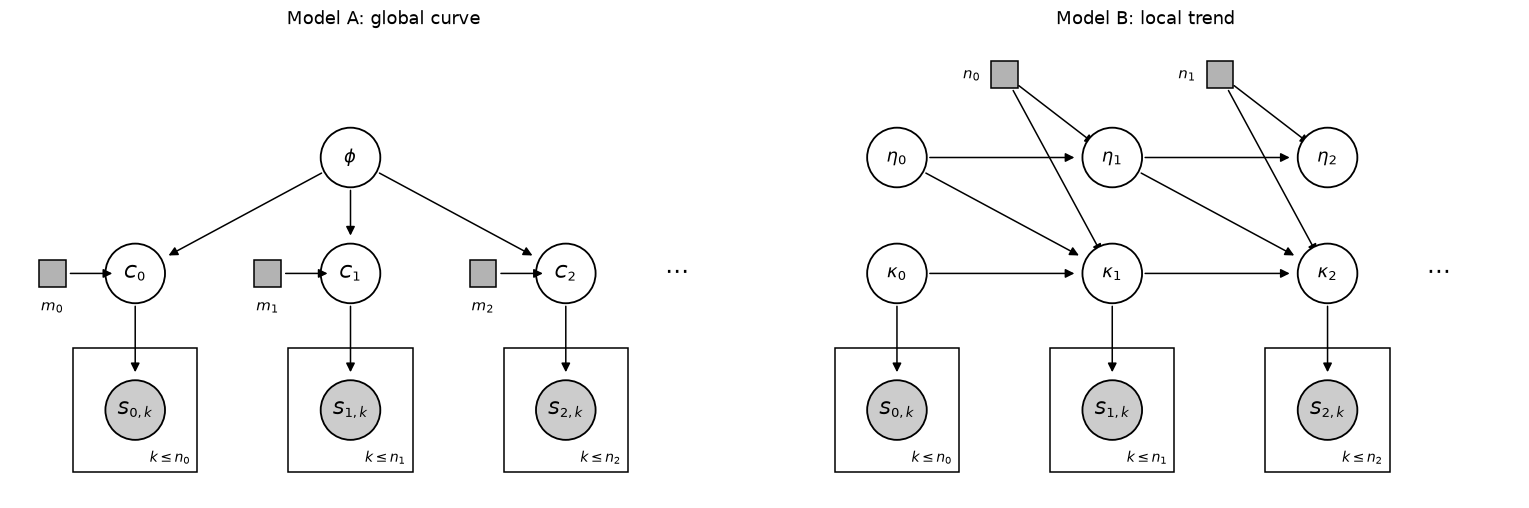

In [7]:
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle


def node(*, ax, xy, label, shaded=False, r=0.36, square=False):
    if square:
        ax.add_patch(Rectangle((xy[0] - 0.16, xy[1] - 0.16), 0.32, 0.32, fc="0.7", ec="k"))
    else:
        ax.add_patch(Circle(xy, r, fc="0.8" if shaded else "white", ec="k", lw=1.2))
    ax.text(*xy, label, ha="center", va="center", fontsize=12)


def arrow(*, ax, a, b, r=0.36):
    d = np.subtract(b, a)
    d = d / np.linalg.norm(d)
    ax.add_patch(
        FancyArrowPatch(
            np.add(a, r * d),
            np.subtract(b, (r + 0.06) * d),
            arrowstyle="-|>",
            mutation_scale=12,
            color="k",
        )
    )


def plate(*, ax, x, y, w, h, label):
    ax.add_patch(Rectangle((x, y), w, h, fill=False, ec="k", lw=1))
    ax.text(x + w - 0.08, y + 0.08, label, ha="right", va="bottom", fontsize=9)


fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))
for ax in (axA, axB):
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_ylim(-0.7, 4.9)

# Model A
axA.set_xlim(-1.5, 7.5)
axA.set_title("Model A: global curve", fontsize=12)
node(ax=axA, xy=(2.6, 3.4), label=r"$\phi$")
for j in range(3):
    x = j * 2.6
    node(ax=axA, xy=(x, 2.0), label=rf"$C_{j}$")
    node(ax=axA, xy=(x - 1.0, 2.0), label="", square=True)
    axA.text(x - 1.0, 1.55, rf"$m_{j}$", ha="center", fontsize=10)
    arrow(ax=axA, a=(x - 1.0, 2.0), b=(x, 2.0), r=0.18)
    arrow(ax=axA, a=(2.6, 3.4), b=(x, 2.0))
    plate(ax=axA, x=x - 0.75, y=-0.4, w=1.5, h=1.5, label=rf"$k \leq n_{j}$")
    node(ax=axA, xy=(x, 0.35), label=rf"$S_{{{j},k}}$", shaded=True)
    arrow(ax=axA, a=(x, 2.0), b=(x, 0.35))
axA.text(6.4, 2.0, r"$\cdots$", fontsize=16, va="center")

# Model B
axB.set_xlim(-1.5, 7.5)
axB.set_title("Model B: local trend", fontsize=12)
for j in range(3):
    x = j * 2.6
    node(ax=axB, xy=(x, 3.4), label=rf"$\eta_{j}$")
    node(ax=axB, xy=(x, 2.0), label=rf"$\kappa_{j}$")
    plate(ax=axB, x=x - 0.75, y=-0.4, w=1.5, h=1.5, label=rf"$k \leq n_{j}$")
    node(ax=axB, xy=(x, 0.35), label=rf"$S_{{{j},k}}$", shaded=True)
    arrow(ax=axB, a=(x, 2.0), b=(x, 0.35))
    if j < 2:
        node(ax=axB, xy=(x + 1.3, 4.4), label="", square=True)
        axB.text(x + 0.9, 4.4, rf"$n_{j}$", ha="center", va="center", fontsize=10)
        arrow(ax=axB, a=(x, 3.4), b=(x + 2.6, 3.4))
        arrow(ax=axB, a=(x, 2.0), b=(x + 2.6, 2.0))
        arrow(ax=axB, a=(x, 3.4), b=(x + 2.6, 2.0))
        arrow(ax=axB, a=(x + 1.3, 4.4), b=(x + 2.6, 2.0), r=0.18)
        arrow(ax=axB, a=(x + 1.3, 4.4), b=(x + 2.6, 3.4), r=0.18)
axB.text(6.4, 2.0, r"$\cdots$", fontsize=16, va="center")
plt.tight_layout()
plt.show()

In A, the only thing shared across cycles is $\phi$, and each $C_j$ is a fresh draw from the curve; the cycles are exchangeable given $\phi$. In B, the state carries over from cycle to cycle and there is no global parameter; the data count enters through $n_j$ scaling the step. Both are hidden Markov models over cycles with the same emission $S_{j,k} \sim \mathrm{Bernoulli}(C_j)$, which is why one filter serves both.

## Toy data

Four skills mirroring Figure 6 of the paper. Ground truth follows the exponential family, which favors Model A.

In [8]:
TRUE = {  # (phi0, phi1, phi2) of the ground-truth competence curve
    "Always fails": (0.0, 0.0, 0.10),
    "Always succeeds": (1.0, 1.0, 0.10),
    "Noisy, not improving": (0.5, 0.5, 0.10),
    "Noisy, improving": (0.1, 0.9, 0.12),
}


def true_curve(*, name, m):
    return float(GlobalCurveModel.mode_fn(phi=np.array(TRUE[name]), m=m))


def simulate(*, name, n_cycles=12, rng=rng):
    cycles, outcomes, m = [], [], 0
    for _ in range(n_cycles):
        n = int(rng.integers(1, 5))
        s_k = rng.random(n) < true_curve(name=name, m=m)
        cycles.append((m, n, int(s_k.sum())))
        outcomes.append(s_k.astype(int))
        m += n
    return cycles, outcomes


DATA = {name: simulate(name=name) for name in TRUE}
for name, (cyc, _) in DATA.items():
    print(f"{name:24s} (m, n, s): {cyc}")

Always fails             (m, n, s): [(0, 4, 0), (4, 3, 0), (7, 3, 0), (10, 3, 0), (13, 4, 0), (17, 1, 0), (18, 1, 0), (19, 1, 0), (20, 2, 0), (22, 3, 0), (25, 4, 0), (29, 3, 0)]
Always succeeds          (m, n, s): [(0, 1, 1), (1, 4, 4), (5, 4, 4), (9, 2, 2), (11, 2, 2), (13, 1, 1), (14, 3, 3), (17, 1, 1), (18, 3, 3), (21, 2, 2), (23, 4, 4), (27, 1, 1)]
Noisy, not improving     (m, n, s): [(0, 2, 1), (2, 2, 1), (4, 2, 1), (6, 4, 1), (10, 1, 0), (11, 2, 0), (13, 1, 0), (14, 1, 0), (15, 3, 1), (18, 4, 1), (22, 2, 2), (24, 4, 1)]
Noisy, improving         (m, n, s): [(0, 3, 1), (3, 2, 1), (5, 4, 1), (9, 3, 2), (12, 3, 2), (15, 2, 2), (17, 1, 1), (18, 4, 4), (22, 4, 4), (26, 4, 3), (30, 1, 1), (31, 3, 2)]


## Running the $2 \times 2$

For every skill, model, and engine: feed the cycles in order, recording after each cycle the *filtered* estimate $P(C_j \mid \text{data through } j)$ and the extrapolation $H$ data points ahead. After the last cycle, run the backward pass to get the *smoothed* estimates $P(C_j \mid \text{all data})$.

The distinction matters for reading the plots. Filtering is what the agent has online, and it is what `estimate()` and `extrapolate()` return; every point on a filtered line was computed without seeing later cycles. Smoothing is the hindsight reconstruction of the competence history, and is only for plots. In each panel the grid engine is solid (blue filtered with its 90% band, orange smoothed) and the particle engine is dashed in the same colors.

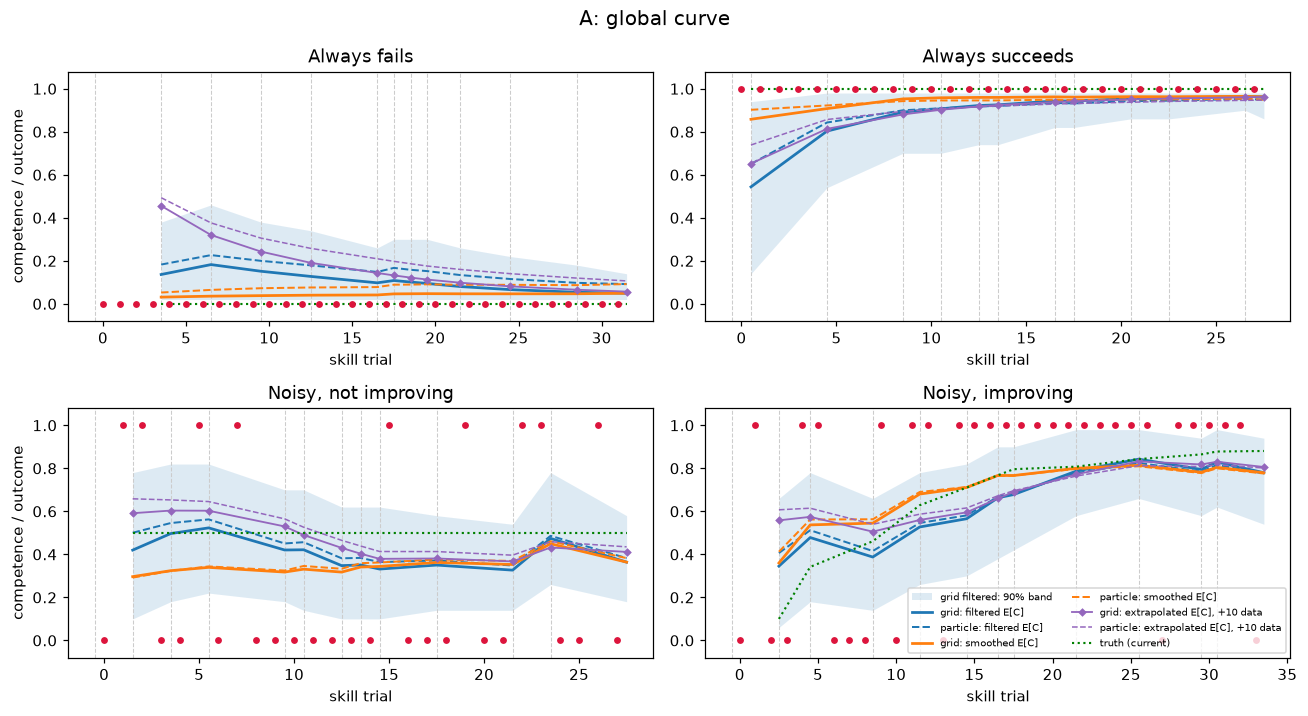

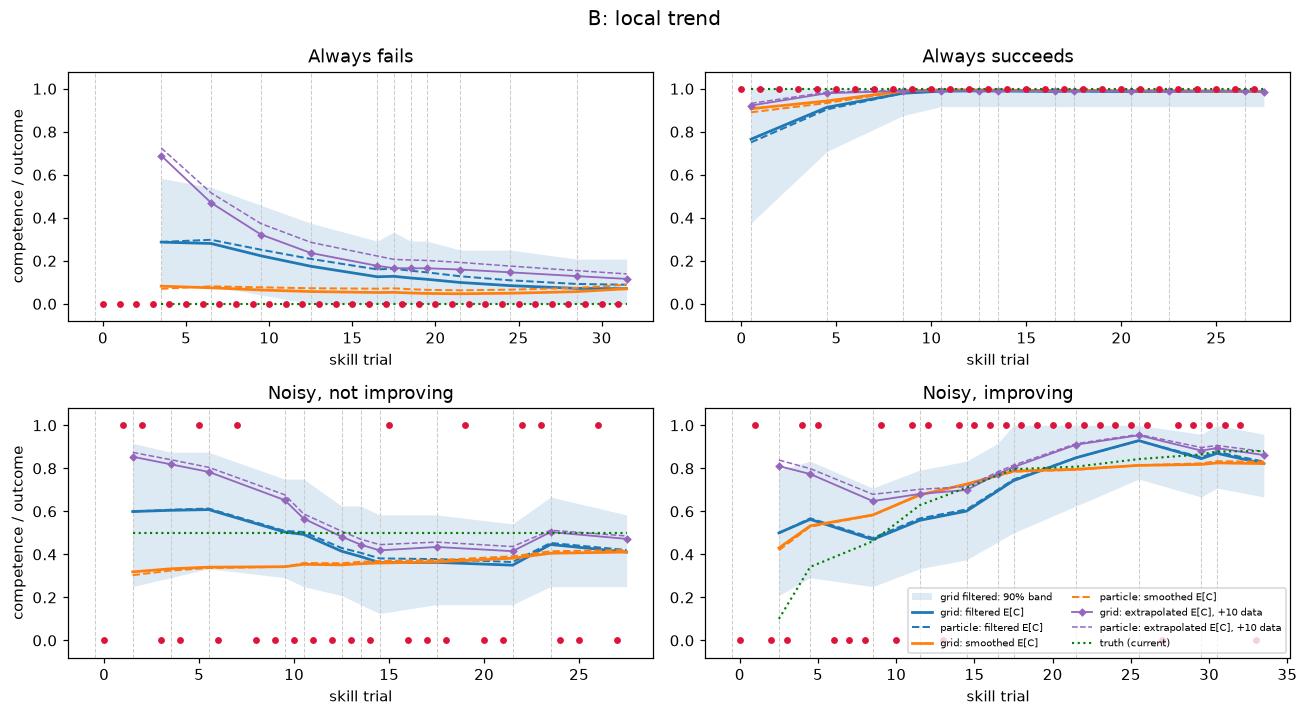

In [9]:
H = 10  # extrapolation horizon in data points


def run(*, model, engine_cls, cycles, **kw):
    eng = engine_cls(model=model, **kw)
    est, ext = [], []
    for m, n, s in cycles:
        eng.update(m=m, n=n, s=s)
        values, weights = eng.estimate()
        est.append(summarize(values=values, weights=weights))  # filtered
        values, weights = eng.extrapolate(m_next=m + n + H)
        ext.append(summarize(values=values, weights=weights))
    smo = [
        summarize(values=v, weights=w) for v, w in eng.history()
    ]  # smoothed, after all data is in
    return np.array(est), np.array(ext), np.array(smo)


RESULTS = {}
for name, (cycles, _) in DATA.items():
    for model in (model_A, model_B):
        RESULTS[name, model.name, "grid"] = run(model=model, engine_cls=GridEngine, cycles=cycles)
        RESULTS[name, model.name, "particle"] = run(
            model=model, engine_cls=ParticleEngine, cycles=cycles, n_particles=20000, rng=rng
        )


def plot_model(*, model):
    fig, axes = plt.subplots(2, 2, figsize=(12, 6.6))
    for ax, (name, (cycles, outcomes)) in zip(axes.ravel(), DATA.items(), strict=True):
        t = 0
        xs = []
        for (_, n, _), out in zip(cycles, outcomes, strict=True):
            ax.axvline(t - 0.5, color="0.8", lw=0.7, ls="--")
            ax.scatter(np.arange(t, t + n), out, color="crimson", s=12, zorder=3)
            xs.append(t + n - 0.5)
            t += n
        xs = np.array(xs)
        g_est, g_ext, g_smo = RESULTS[name, model.name, "grid"]
        p_est, p_ext, p_smo = RESULTS[name, model.name, "particle"]
        ax.fill_between(
            xs,
            g_est[:, 1],
            g_est[:, 2],
            color="tab:blue",
            alpha=0.15,
            lw=0,
            label="grid filtered: 90% band",
        )
        ax.plot(xs, g_est[:, 0], color="tab:blue", lw=1.8, label="grid: filtered E[C]")
        ax.plot(xs, p_est[:, 0], color="tab:blue", lw=1.3, ls="--", label="particle: filtered E[C]")
        ax.plot(xs, g_smo[:, 0], color="tab:orange", lw=1.8, label="grid: smoothed E[C]")
        ax.plot(
            xs, p_smo[:, 0], color="tab:orange", lw=1.3, ls="--", label="particle: smoothed E[C]"
        )
        ax.plot(
            xs,
            g_ext[:, 0],
            color="tab:purple",
            lw=1.2,
            marker="D",
            ms=3,
            label=f"grid: extrapolated E[C], +{H} data",
        )
        ax.plot(
            xs,
            p_ext[:, 0],
            color="tab:purple",
            lw=1.0,
            ls="--",
            label=f"particle: extrapolated E[C], +{H} data",
        )
        ax.plot(
            xs,
            [true_curve(name=name, m=m) for m, _, _ in cycles],
            color="green",
            ls=":",
            lw=1.4,
            label="truth (current)",
        )
        ax.set_title(name)
        ax.set_ylim(-0.08, 1.08)
        ax.set_xlabel("skill trial")
    axes[0, 0].set_ylabel("competence / outcome")
    axes[1, 0].set_ylabel("competence / outcome")
    axes[1, 1].legend(fontsize=6.5, loc="lower right", ncol=2)
    fig.suptitle(model.name, fontsize=13)
    plt.tight_layout()
    plt.show()


plot_model(model=model_A)
plot_model(model=model_B)

In [10]:
print(f"{'skill':24s} {'model':17s} {'engine':9s} {'E[C_now]':>9} {'E[C_+H]':>8} {'truth_+H':>9}")
for name, (cycles, _) in DATA.items():
    m_end = cycles[-1][0] + cycles[-1][1]
    for model in (model_A, model_B):
        for eng in ("grid", "particle"):
            est, ext, _ = RESULTS[name, model.name, eng]
            print(
                f"{name:24s} {model.name:17s} {eng:9s} "
                f"{est[-1, 0]:>9.3f} {ext[-1, 0]:>8.3f} "
                f"{true_curve(name=name, m=m_end + H):>9.3f}"
            )

skill                    model             engine     E[C_now]  E[C_+H]  truth_+H
Always fails             A: global curve   grid          0.049    0.057     0.000
Always fails             A: global curve   particle      0.092    0.107     0.000
Always fails             B: local trend    grid          0.070    0.116     0.000
Always fails             B: local trend    particle      0.089    0.139     0.000
Always succeeds          A: global curve   grid          0.962    0.962     1.000
Always succeeds          A: global curve   particle      0.949    0.947     1.000
Always succeeds          B: local trend    grid          0.987    0.986     1.000
Always succeeds          B: local trend    particle      0.988    0.990     1.000
Noisy, not improving     A: global curve   grid          0.364    0.411     0.500
Noisy, not improving     A: global curve   particle      0.383    0.435     0.500
Noisy, not improving     B: local trend    grid          0.411    0.472     0.500
Noisy, not impro

## Reading the results

- **Grid and particle agree** wherever the particle set is not degenerate; that agreement is the check that the two engines implement the same model. The residual gap on Model A is the standard weakness of a bootstrap particle filter for a *static* parameter: $\phi$ is never rejuvenated, so after a few resampling steps only a handful of distinct $\phi$ values survive. The remedy (an MCMC move on $\phi$ inside each particle, i.e. resample-move) changes `ParticleEngine` and nothing else.
- **Smoothed vs. filtered.** The smoothed curves are what one would naively want a "competence history" plot to show, and on the "always" skills they are pinned to the truth from the first cycle because later outcomes flow backward. The filtered curves lag, and that lag is real: it is the belief EES was acting on at the time. The mechanism by which later data reaches earlier cycles differs: in Model A it is the static $\phi$, which ties every cycle to every other, so smoothing mostly sharpens the plateau level; in Model B it is the transition, so smoothing straightens out the local wandering of the filtered curve. The particle smoother is an ancestral trace, so its early-cycle values come from very few distinct ancestors (path degeneracy) and are the least trustworthy numbers in the plots.
- **Model A extrapolates further and more confidently** because it assumes the exponential shape; on the "always" skills its extrapolation is flat, as EES wants. **Model B extrapolates the local slope**, damped by $\rho$, so it is slower to conclude that an always-failing skill will never improve and its band widens with $H$.
- **Neither model has to change to change the inference, and neither engine has to change to change the model.** EES only ever calls `estimate()` and `extrapolate(m_next)`.

---

# Appendix (optional)

## A1. What each model believes a priori

Competence curves sampled from each prior, with no outcomes observed. Model A's curves are exponentials with a random plateau; Model B's are damped random walks whose slope decays with $\rho$.

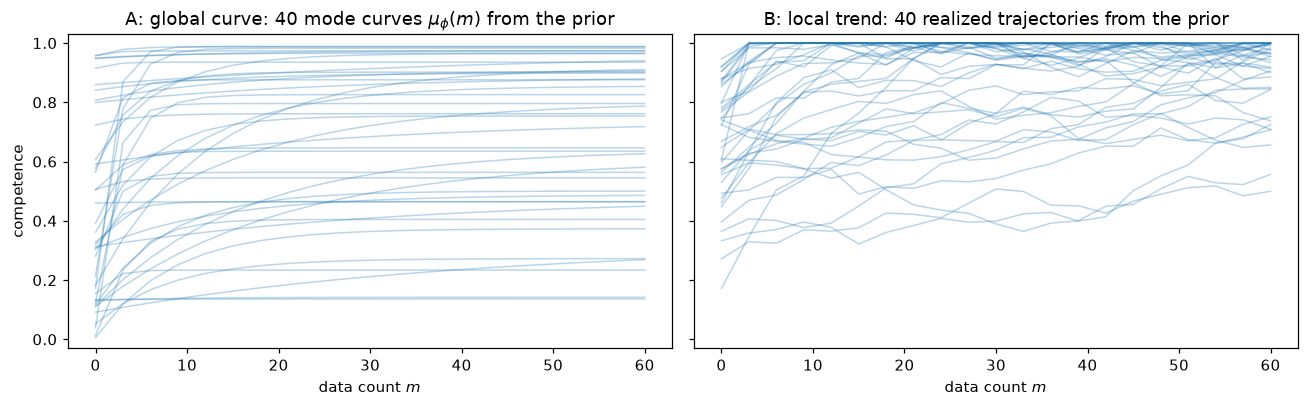

In [11]:
def prior_trajectories(*, model, n_curves, ms, rng):
    """Sample n_curves realized-competence trajectories across ms from the prior alone."""
    z = model.sample_initial(size=n_curves, rng=rng)
    out = [model.competence(z=z)]
    for m_from, m_to in zip(ms[:-1], ms[1:], strict=True):
        z = model.sample_transition(z=z, m_from=m_from, m_to=m_to, rng=rng)
        out.append(model.competence(z=z))
    return np.array(out)  # [len(ms), n_curves]


ms = np.arange(0, 61, 3)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)

# Model A: the latent object is the curve itself, so plot mode curves mu_phi(m) for sampled phi.
phi = model_A.sample_initial(size=40, rng=rng)
axes[0].plot(
    ms,
    np.array([GlobalCurveModel.mode_fn(phi=phi, m=m) for m in ms]),
    color="tab:blue",
    alpha=0.3,
    lw=1,
)
axes[0].set_title(f"{model_A.name}: 40 mode curves $\\mu_\\phi(m)$ from the prior")

# Model B: there is no curve, only a state that moves, so plot realized trajectories.
axes[1].plot(
    ms,
    prior_trajectories(model=model_B, n_curves=40, ms=ms, rng=rng),
    color="tab:blue",
    alpha=0.3,
    lw=1,
)
axes[1].set_title(f"{model_B.name}: 40 realized trajectories from the prior")

for ax in axes:
    ax.set_xlabel("data count $m$")
    ax.set_ylim(-0.03, 1.03)
axes[0].set_ylabel("competence")
plt.tight_layout()
plt.show()

(Model A's *realized* competence $C_j$ is a fresh Beta draw around $\mu_\phi(m_j)$ at each cycle, with spread set by $\kappa$, so a plot of realized values would show independent jitter around these curves. The curve, not the jitter, is what the model extrapolates.)

## A2. Extensions

1. Make $\rho, \sigma_\kappa, \sigma_\eta$ latent in Model B, the way $\kappa$ is latent in Model A. The particle engine works unchanged; the grid engine's state count grows multiplicatively.
2. Add a rejuvenation move to `ParticleEngine` and confirm the Model A gap closes.
3. Replace the ancestral-trace particle smoother with backward simulation (or a fixed-lag smoother) and check that the early-cycle degeneracy disappears.
4. Generate a second toy data set from Model B's prior so the comparison is not tilted toward Model A.
5. A hierarchical prior tying $\phi$ (or $\rho$) across skills with the same parent, mirroring weight sharing in the parameter policies.